In [273]:
import numpy as np
import matplotlib.pyplot as plt
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [274]:
import matplotlib.pyplot as plt
from dreimac import ToroidalCoords, GeometryExamples, CircleMapUtils
from persim import plot_diagrams

In [275]:
def find_partition_for_cocycle(tc, cocycle_idx, std_thresh=0.01):
    harm_reps_and_integrals = tc._harm_reps
    harm_reps,_ = zip(*harm_reps_and_integrals)
    from dreimac.utils import CohomologyUtils

    theta = CohomologyUtils.one_cocycle_to_matrix(dist_mat=tc._dist_land_land, 
                                                threshold=tc._r_cover,
                                                lookup_table=tc._cns_lookup_table,
                                                n_points = tc._n_landmarks,
                                                cocycle_as_vector=harm_reps[cocycle_idx])
    bad_idx = []
    good_idx = []
    for i in range(len(theta)):
        vector = theta[i,:]
        nonzero_vector = vector[vector!=0]

        if len(nonzero_vector) == 0:
            bad_idx.append(i)
        else:
            standard_deviation = np.std(nonzero_vector)
            if standard_deviation < std_thresh:
                bad_idx.append(i)
            else:
                good_idx.append(i)
    return good_idx, bad_idx


# Theta shape

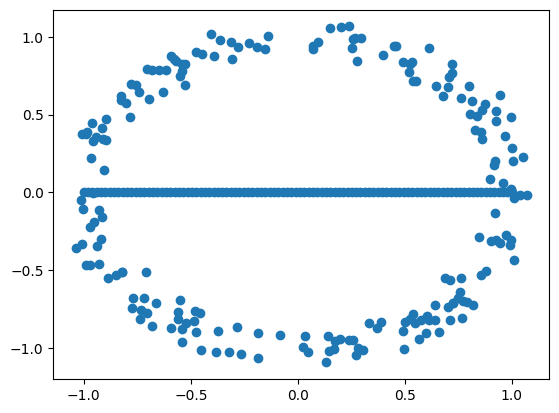

In [276]:
X1 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
X2 = np.zeros(shape=(100, 2))
X2[:, 0] = np.linspace(-1, 1, num =100)
X = np.vstack([X1, X2])
plt.scatter(X[:,0], X[:,1])

In [ ]:
tc = ToroidalCoords(X, n_landmarks=len(X))

In [278]:
tc_theta = tc.get_coordinates(cocycle_idxs=[0,1])

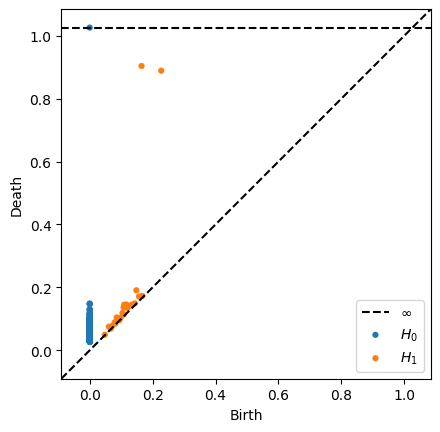

In [279]:
plot_diagrams(tc.dgms_)

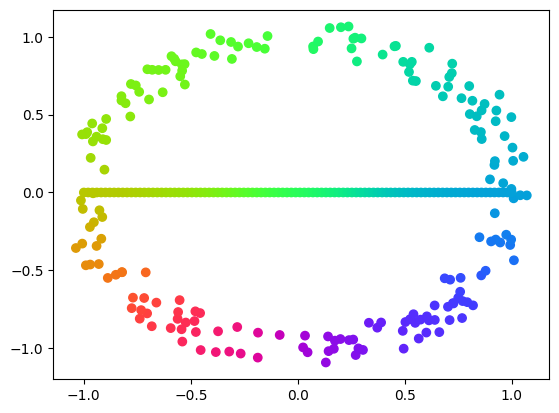

In [280]:
plt.scatter(X[:,0], X[:,1], c = CircleMapUtils.to_sinebow(tc_theta[0,:]))
#plt.scatter(X[tc._idx_land, 0], X[tc._idx_land, 1], color='black')

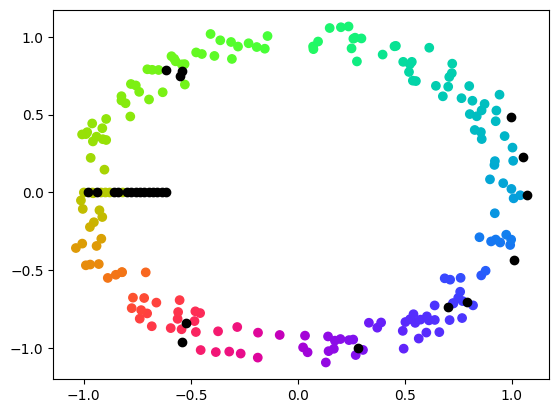

In [281]:
good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx= 0, std_thresh=0.0001)
plt.scatter(X[good_idx,0], X[good_idx,1], c = CircleMapUtils.to_sinebow(tc_theta[0,good_idx]))
plt.scatter(X[bad_idx,0], X[bad_idx,1], c= 'black')

# Wedge of Circles

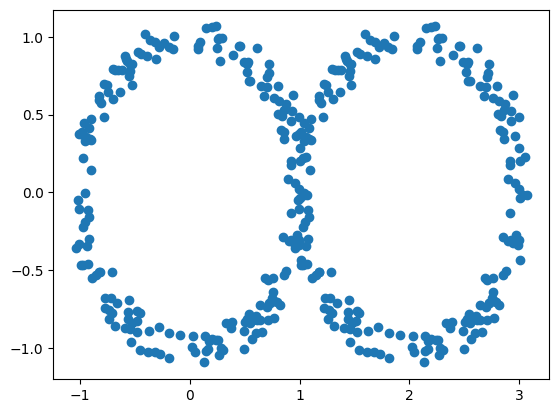

In [282]:
circ1 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
circ2 = GeometryExamples.noisy_circle(n_samples=200, noise_size=0.2)
circ2[:,0] = circ2[:,0] + 2
X = np.vstack([circ1, circ2])
plt.scatter(X[:,0], X[:,1])

In [283]:
tc = ToroidalCoords(X, n_landmarks=400)
tc_theta = tc.get_coordinates(perc=0.15,cocycle_idxs=[0,1])

In [284]:
id_land = tc._idx_land

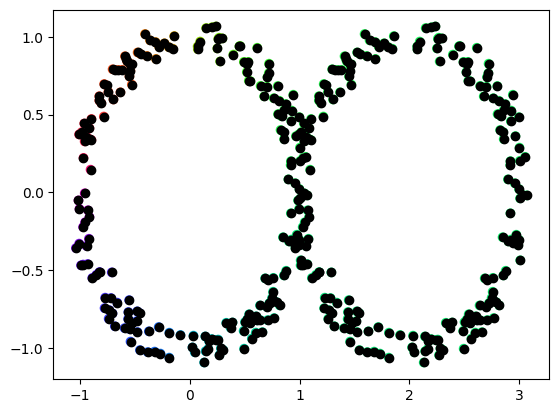

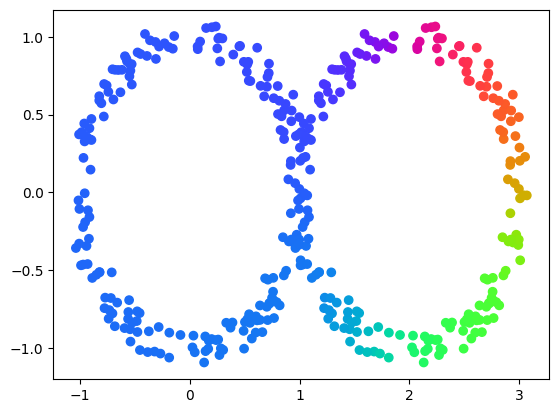

In [285]:
plt.scatter(X[:,0], X[:,1], c=CircleMapUtils.to_sinebow(tc_theta[0,:]))
plt.scatter(X[id_land,0], X[id_land,1], c="black")
plt.show()
plt.scatter(X[:,0], X[:,1], c=CircleMapUtils.to_sinebow(tc_theta[1,:]))

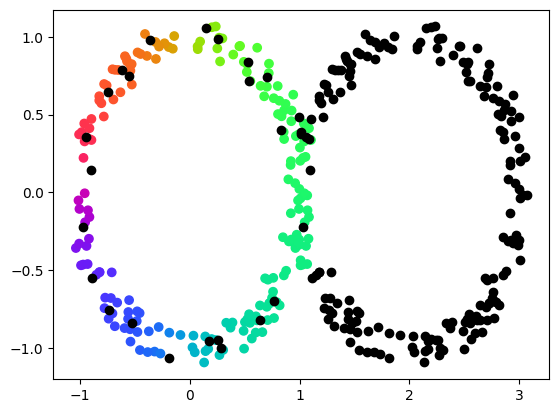

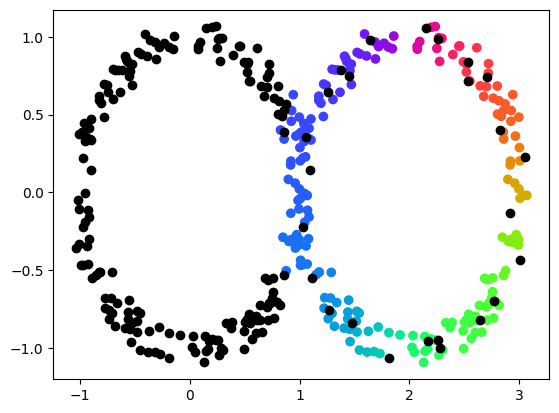

In [286]:
for id in [0,1]:
    good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx=id, std_thresh=0.005)
    plt.scatter(X[good_idx,0], X[good_idx,1], c = CircleMapUtils.to_sinebow(tc_theta[id,good_idx]))
    plt.scatter(X[bad_idx,0], X[bad_idx,1], c= 'black')
    plt.show()

# Sphere wedge circle

In [ ]:
import plotly.graph_objects as go

n_data = 400
theta = 2*np.pi*np.random.rand(n_data)
phi = np.pi*np.random.rand(n_data)
data = np.zeros((3,n_data))
data[0] = 2*np.cos(theta)*np.sin(phi) - 4
data[1] = 2*np.sin(theta)*np.sin(phi) - 0
data[2] = 2*np.cos(phi) - 0

beta = 2*np.pi * np.random.rand(n_data)
atad = np.zeros((3,n_data))
atad[0] = 2*np.cos(beta)
atad[1] = 2*np.sin(beta)
atad[2] = 0

data = np.hstack([data,atad])
#add noise
#data += 0.2 * np.random.randn(*data.shape)

# Plot the data 
fig = go.Figure(data=[go.Scatter3d(
    x=data[0], y=data[1], z=data[2], 
    mode ='markers', 
    marker=dict(size = 1.5 , color = 'grey'))])
X = data.T
fig.update_layout( width=900, height=450)
fig.show()

In [ ]:
tc = ToroidalCoords(X, n_landmarks=len(X))
tc_theta = tc.get_coordinates(cocycle_idxs=[0])
px.scatter_3d(x=X[tc._idx_land,0], y=X[tc._idx_land,1], z=X[tc._idx_land,2])

In [ ]:
import plotly.express as px
good_idx, bad_idx = find_partition_for_cocycle(tc, cocycle_idx= 0, std_thresh=0.001)
print(len(good_idx))
print(len(bad_idx))

18
62


In [ ]:

fig = go.Figure(data=[go.Scatter3d(
    x=X[good_idx, 0], y=X[good_idx, 1], z=X[good_idx, 2], 
    mode ='markers', 
    marker=dict(size = 1.5 , color = tc_theta[0][good_idx])),
    go.Scatter3d(
    x=X[bad_idx, 0], y=X[bad_idx, 1], z=X[bad_idx, 2], 
    mode ='markers', 
    marker=dict(size = 1.5 , color = 'gray'))
    ])

fig.update_layout( width=900, height=450)
fig.show()

In [ ]:
data.shape

(3, 2000)